# Contents Overview

**Project Objectives**: Define the goals of this analysis and what we aim to uncover about customer churn.

**Data Import & Inspection**: Loading the dataset, checking its structure, and understanding the variables.

**Data Preparation**: Cleaning the data, handling missing values, standardizing column names, and creating any derived variables.

**Feature Exploration**: Examining key metrics such as tenure, spending, satisfaction, and engagement levels.

**Exploratory Data Analysis (EDA)**:

1. Customer Behavior Analysis: Investigating churn patterns across demographics, purchase history, and activity levels.

2. Advanced Relationships: Exploring correlations and interactions between variables to identify the main drivers of churn.

**Customer Behavior Scatterplots by Churn**: Highlighting key findings and actionable recommendations for improving retention.

**Customer Behavioral Relationships – Regression and Scatter Analysis**

**Conclusion**: Wrapping up the analysis with overall takeaways and strategic implications.

# Project Objectives

The purpose of this project is to investigate customer churn in an e-commerce setting. The specific aims are:

**Understand the dataset**: Get familiar with the structure, variables, and customer information.

**Prepare the data for analysis**: Clean, transform, and enrich data to make it analysis-ready.

**Identify churn patterns**: Explore behavioral, demographic, and transaction factors related to churn.

**Generate actionable insights**: Highlight high-risk segments and suggest strategies to improve customer retention.

**Support data-driven decisions**: Provide visualizations and summaries to inform marketing and retention strategies.

# Data Import & Inspection
The data was downloaded from Kaggle:

https://www.kaggle.com/datasets/samuelsemaya/e-commerce-customer-churn?utm_source=chatgpt.com

In [24]:
%matplotlib notebook
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re
%matplotlib inline

In [25]:
# Loading the dataset
ecom_churn_data = pd.read_csv("/Users/macbookprom116gb/Downloads/data_ecommerce_customer_churn.csv")

# Showing all columns and first rows
pd.set_option('display.max_columns', None)
ecom_churn_data.head()


,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


In [26]:
ecom_churn_data.columns

Index(['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered',
       'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus',
       'NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount',
       'Churn'],
      dtype='object')

In [27]:
ecom_churn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   object 
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   object 
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 338.8+ KB


The dataset contains 11 columns and 3941 rows.

Data types:

Most columns are numeric (Tenure, WarehouseToHome, NumberOfDeviceRegistered, SatisfactionScore, NumberOfAddress, Complain, DaySinceLastOrder, CashbackAmount, Churn).

Some columns are categorical (PreferedOrderCat, MaritalStatus).

Missing data: DaySinceLastOrder has some missing values (NaN) that need handling.

Column names: They are mostly descriptive, but some could be standardized for consistency (e.g., PreferedOrderCat → PreferredOrderCategory).

Initial summary statistics for numeric columns (based on the snippet):

Tenure ranges from 7 to 30 (months)

WarehouseToHome ranges from 13 to 29 km

NumberOfDeviceRegistered ranges from 3 to 4

SatisfactionScore ranges from 1 to 4

NumberOfAddress ranges from 2 to 8

CashbackAmount ranges from 129.29 to 322.17

Target variable: Churn is binary (0 = active, 1 = churned), which will be the focus of the analysis.

In [28]:
print(ecom_churn_data.describe())

            Tenure  WarehouseToHome  NumberOfDeviceRegistered  \
count  3747.000000      3772.000000               3941.000000   
mean     10.081398        15.650583                  3.679269   
std       8.498864         8.452301                  1.013938   
min       0.000000         5.000000                  1.000000   
25%       2.000000         9.000000                  3.000000   
50%       9.000000        14.000000                  4.000000   
75%      16.000000        21.000000                  4.000000   
max      61.000000       127.000000                  6.000000   

       SatisfactionScore  NumberOfAddress     Complain  DaySinceLastOrder  \
count        3941.000000      3941.000000  3941.000000        3728.000000   
mean            3.088302         4.237757     0.282416           4.531652   
std             1.381832         2.626699     0.450232           3.667648   
min             1.000000         1.000000     0.000000           0.000000   
25%             2.000000     

# Data Preparation

In [29]:
# Renaming  columns for consistency and clarity
ecom_churn_data.rename(columns={
    "Tenure": "Tenure_Months",
    "WarehouseToHome": "Warehouse_Distance_km",
    "NumberOfDeviceRegistered": "Devices_Registered",
    "PreferedOrderCat": "PreferredOrderCategory",
    "SatisfactionScore": "Satisfaction_Score",
    "MaritalStatus": "Marital_Status",
    "NumberOfAddress": "Addresses_Registered",
    "Complain": "Has_Complained",
    "DaySinceLastOrder": "Days_Since_Last_Order",
    "CashbackAmount": "Cashback_Amount",
    "Churn": "Churn"
},inplace=True)

ecom_churn_data.head()


,Tenure_Months,Warehouse_Distance_km,Devices_Registered,PreferredOrderCategory,Satisfaction_Score,Marital_Status,Addresses_Registered,Has_Complained,Days_Since_Last_Order,Cashback_Amount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


In [30]:
# Checking missing values 
ecom_churn_data.isnull().sum()

# Filling missing Days_Since_Last_Order with median 
ecom_churn_data.fillna({'Days_Since_Last_Order': ecom_churn_data['Days_Since_Last_Order'].median()}, inplace=True)



In [31]:
# Converting categorical columns to category type
cat_cols = ['PreferredOrderCategory', 'Marital_Status', 'Has_Complained', 'Churn']
for col in cat_cols:
    ecom_churn_data[col] = ecom_churn_data[col].astype('category')


In [32]:
# Checking for duplicates
duplicates = ecom_churn_data.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# If any duplicates exist, droping it
ecom_churn_data.drop_duplicates(inplace=True)


Number of duplicate rows: 672


# Feature Exploration

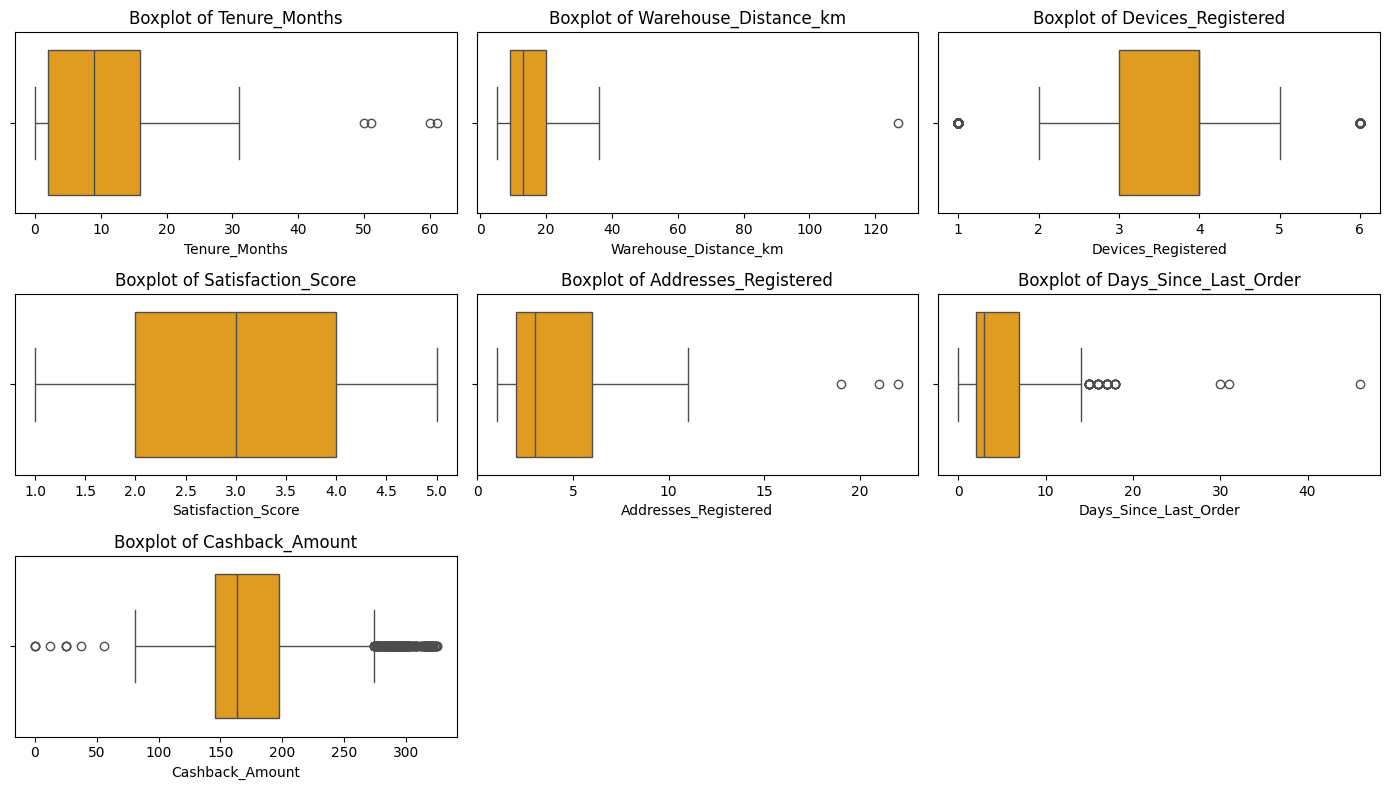

In [33]:
# Selecting all numeric columns except Churn which is categorical 
numeric_cols = ecom_churn_data.select_dtypes(include=['int64', 'float64']).columns

# Plot boxplots for each numeric variable
plt.figure(figsize=(14, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=ecom_churn_data, x=col, color='orange')
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()




Overall, the dataset shows no severe data issues. There are no missing values or clearly erroneous entries, and the numeric columns contain extreme values that are mostly valid. These extreme values represent long-term customers, high spenders, or inactive users, all of which are meaningful for churn analysis. Therefore, no additional cleaning is necessary, and the data can be used as-is for exploratory analysis, correlation studies, and visualizations.

# Exploratory Data Analysis (EDA)

**Customer Behavior Analysis**

First of all, we designed a code to explore the target variable (Churn), which tells us whether a customer has stopped purchasing (churned) or is still active. Understanding the distribution of this variable is crucial because it sets the stage for all subsequent analysis.

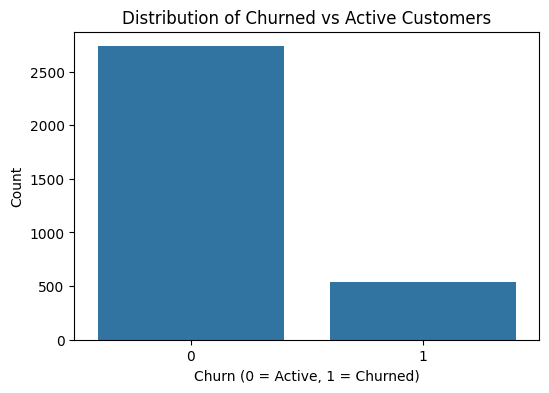

Churn counts:
 Churn
0    2735
1     534
Name: count, dtype: int64

Churn proportion:
 Churn
0    0.836647
1    0.163353
Name: count, dtype: float64


In [12]:
# Checking Churn Distribution
plt.figure(figsize=(6,4))
sns.countplot(data=ecom_churn_data, x='Churn')
plt.title('Distribution of Churned vs Active Customers')
plt.xlabel('Churn (0 = Active, 1 = Churned)')
plt.ylabel('Count')
plt.show()
churn_counts = ecom_churn_data['Churn'].value_counts()
print("Churn counts:\n", churn_counts)
print("\nChurn proportion:\n", churn_counts / len(ecom_churn_data))





It shows that about 16% of customers have churned and 84% are still active, we can move on to the numeric variables now. 

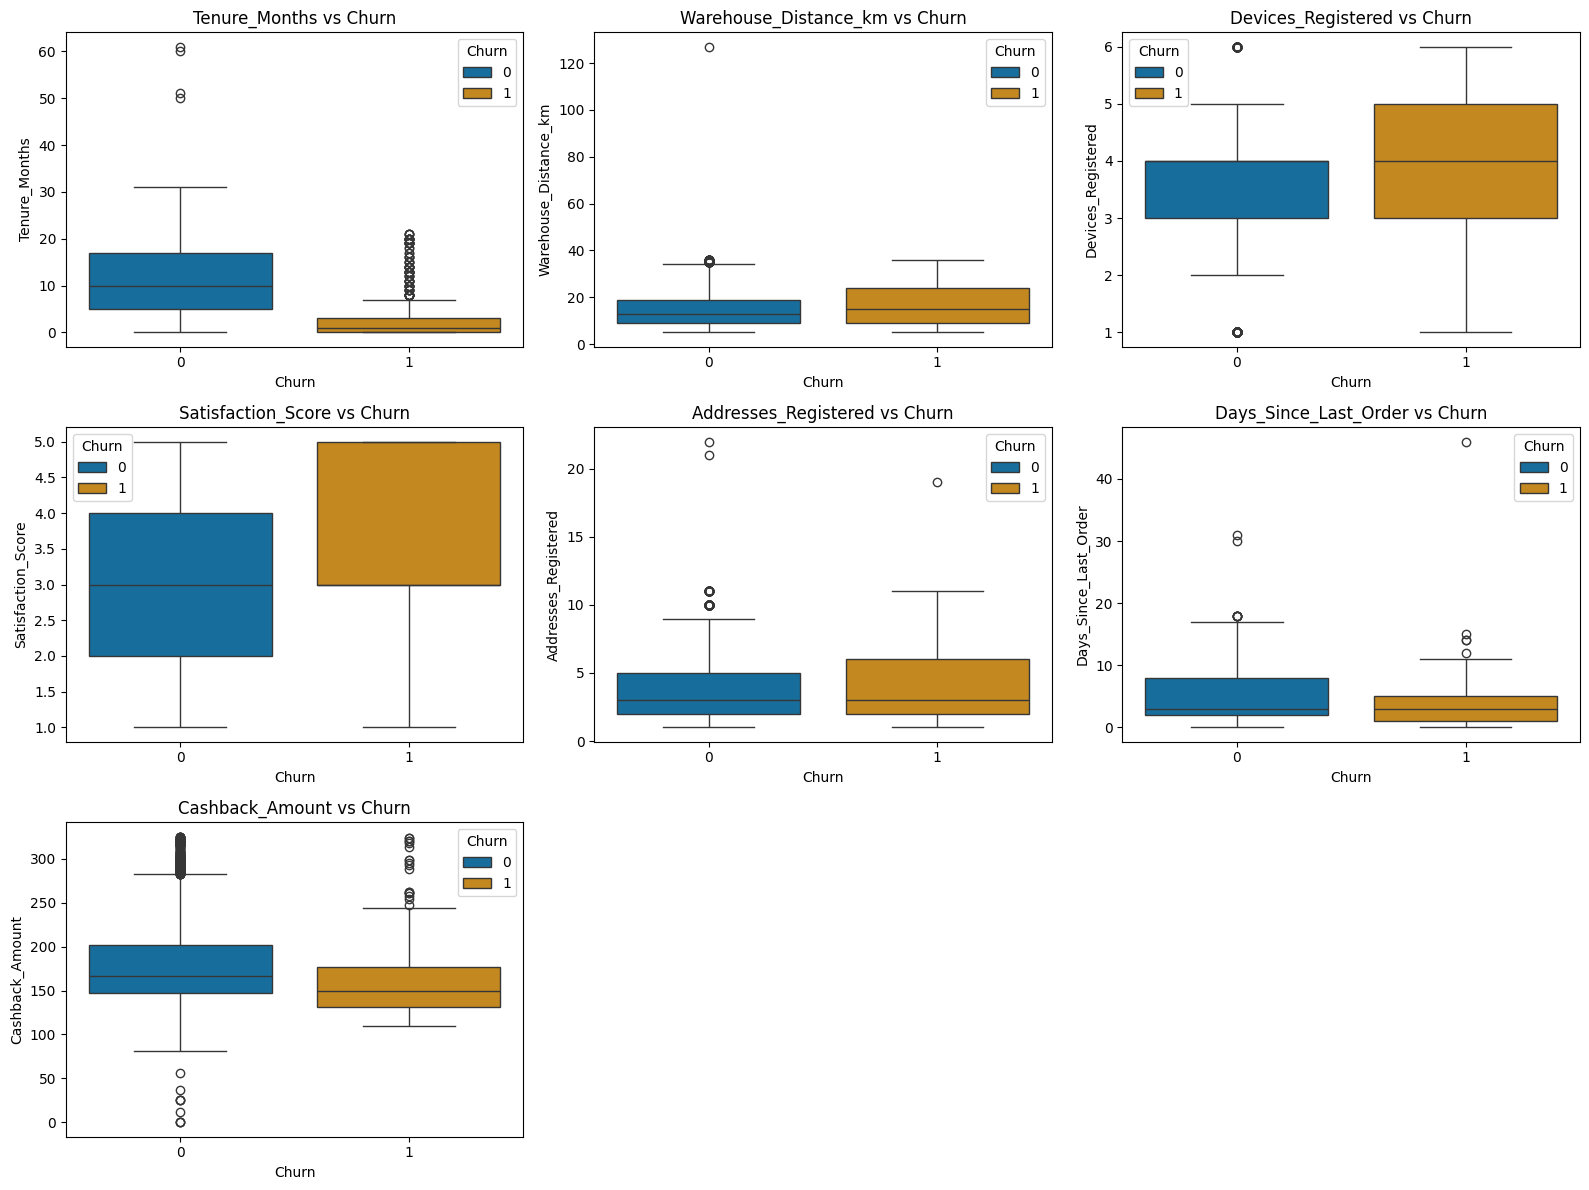

Tenure_Months                                                   \
              count       mean       std  min  25%   50%   75%   max   
Churn                                                                  
0            2623.0  11.483416  8.532189  0.0  5.0  10.0  17.0  61.0   
1             486.0   3.183128  5.246639  0.0  0.0   1.0   3.0  21.0   

      Warehouse_Distance_km                                                    \
                      count       mean       std  min  25%   50%   75%    max   
Churn                                                                           
0                    2645.0  15.236295  8.503388  5.0  9.0  13.0  19.0  127.0   
1                     489.0  16.989775  8.782078  5.0  9.0  15.0  24.0   36.0   

      Devices_Registered                                               \
                   count      mean       std  min  25%  50%  75%  max   
Churn                                                                   
0                 2735.0  3.627057  1.011926  1.0  3.0  4.0  4.0  6.0   
1                  534.0  3.928839  1.009612  1.0  3.0  4.0  5.0  6.0   

      Satisfaction_Score                                               \
                   count      mean       std  min  25%  50%  75%  max   
Churn                                                                   
0                 2735.0  2.959781  1.394363  1.0  2.0  3.0  4.0  5.0   
1                  534.0  3.331461  1.358961  1.0  3.0  3.0  5.0  5.0   

      Addresses_Registered                                                \
                     count      mean       std  min  25%  50%  75%   max   
Churn                                                                      
0                   2735.0  4.169287  2.582835  1.0  2.0  3.0  5.0  22.0   
1                    534.0  4.498127  2.809625  1.0  2.0  3.0  6.0  19.0   

      Days_Since_Last_Order                                                \
                      count      mean       std  min  25%  50%  75%   max   
Churn                                                                       
0                    2735.0  4.688848  3.591128  0.0  2.0  3.0  8.0  31.0   
1                     534.0  3.290262  3.480853  0.0  1.0  3.0  5.0  46.0   

      Cashback_Amount                                                   \
                count        mean        std     min       25%     50%   
Churn                                                                    
0              2735.0  180.698468  50.465056    0.00  147.3150  166.27   
1               534.0  160.513202  38.766515  110.09  131.4525  149.62   

                         
            75%     max  
Churn                    
0      201.3700  324.99  
1      176.5025  323.59

In [13]:
# Numeric Variables vs Churn
numeric_cols = ['Tenure_Months', 'Warehouse_Distance_km', 'Devices_Registered', 
                'Satisfaction_Score', 'Addresses_Registered', 'Days_Since_Last_Order', 'Cashback_Amount']

plt.figure(figsize=(16,12))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x='Churn', y=col, data=ecom_churn_data, hue='Churn', palette='colorblind', dodge=False)
    plt.title(f'{col} vs Churn')
plt.tight_layout()
plt.show()

numeric_summary = ecom_churn_data.groupby('Churn', observed=False)[numeric_cols].describe()
numeric_summary


**Tenure**, **days since last order**, **satisfaction**, and **cashback** appear to be the most influential numeric factors affecting churn. Other variables like **warehouse distance** or **number of devices/addresses** may play a smaller role but can still add context.

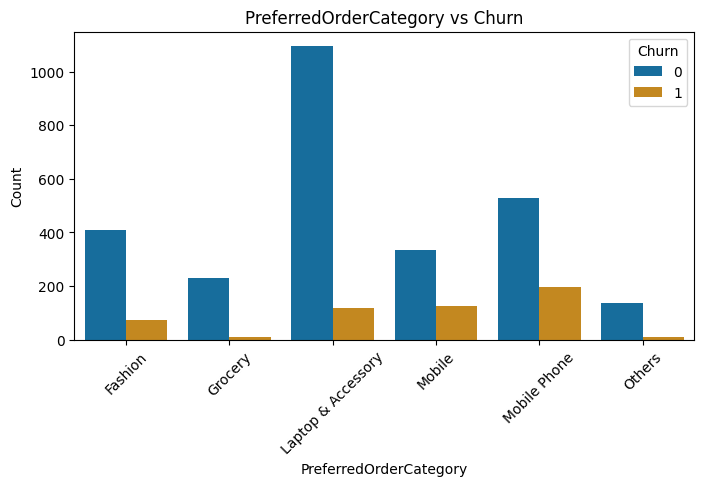

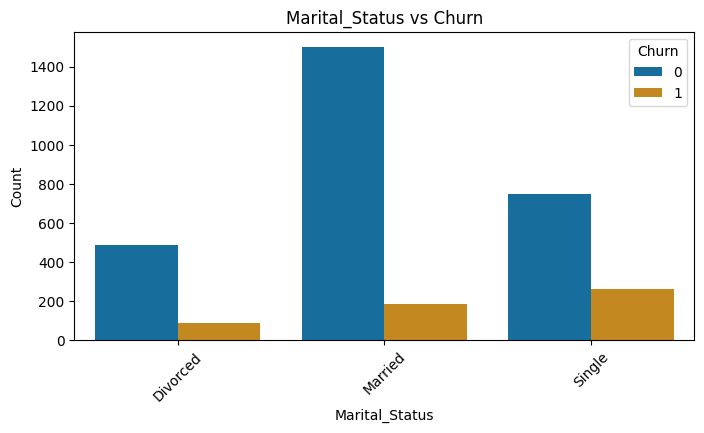

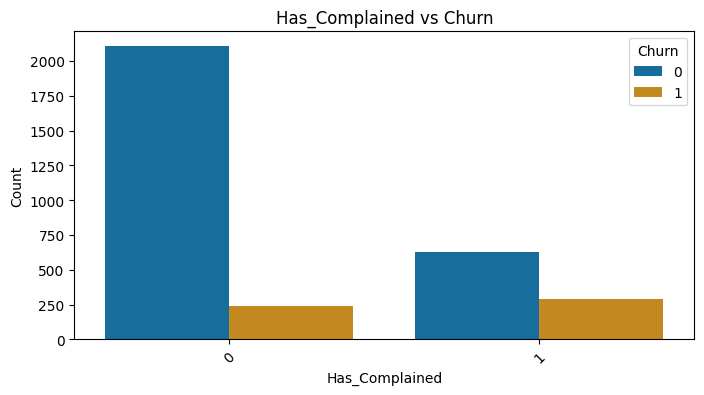

In [14]:
# Categorical Variables vs Churn
categorical_cols = ['PreferredOrderCategory', 'Marital_Status', 'Has_Complained']

for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, hue='Churn', data=ecom_churn_data, palette='colorblind')
    plt.title(f'{col} vs Churn')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.legend(title='Churn')
    plt.show()


Across these categorical plots, **customer satisfaction** and **experience** appear to play a major role in retention. Categories tied to higher complaint rates or lower satisfaction correlate strongly with churn. In contrast, customers with **preferred product categories** or **stable demographics** (like married users) tend to remain active.

**Advanced Relationships**

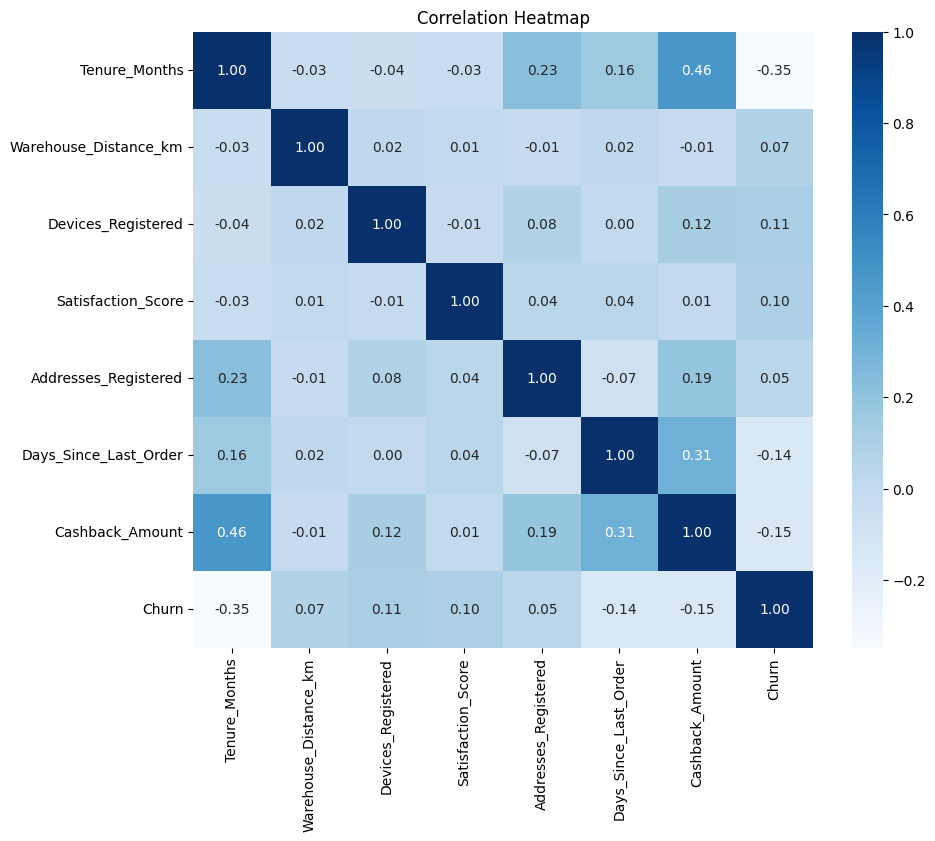

In [15]:
# Correlation Analysis for numeric columns
plt.figure(figsize=(10,8))
corr_matrix = ecom_churn_data[numeric_cols + ['Churn']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

The correlation analysis confirms earlier insights from the boxplots. Customers with higher satisfaction and longer tenure are less likely to churn, indicating that loyalty and positive experiences are strong retention factors. In contrast, higher delivery distances, longer inactivity periods, and lower cashback amounts show positive correlations with churn, suggesting that disengaged or less satisfied customers are more likely to leave. Overall, maintaining customer satisfaction, engagement, and convenience appears crucial for reducing churn and improving long-term retention.

# Customer Behavior Scatterplots by Churn
Visualizing relationships among Cashback, Tenure, Warehouse Distance, and Days Since Last Order, colored by churn status:



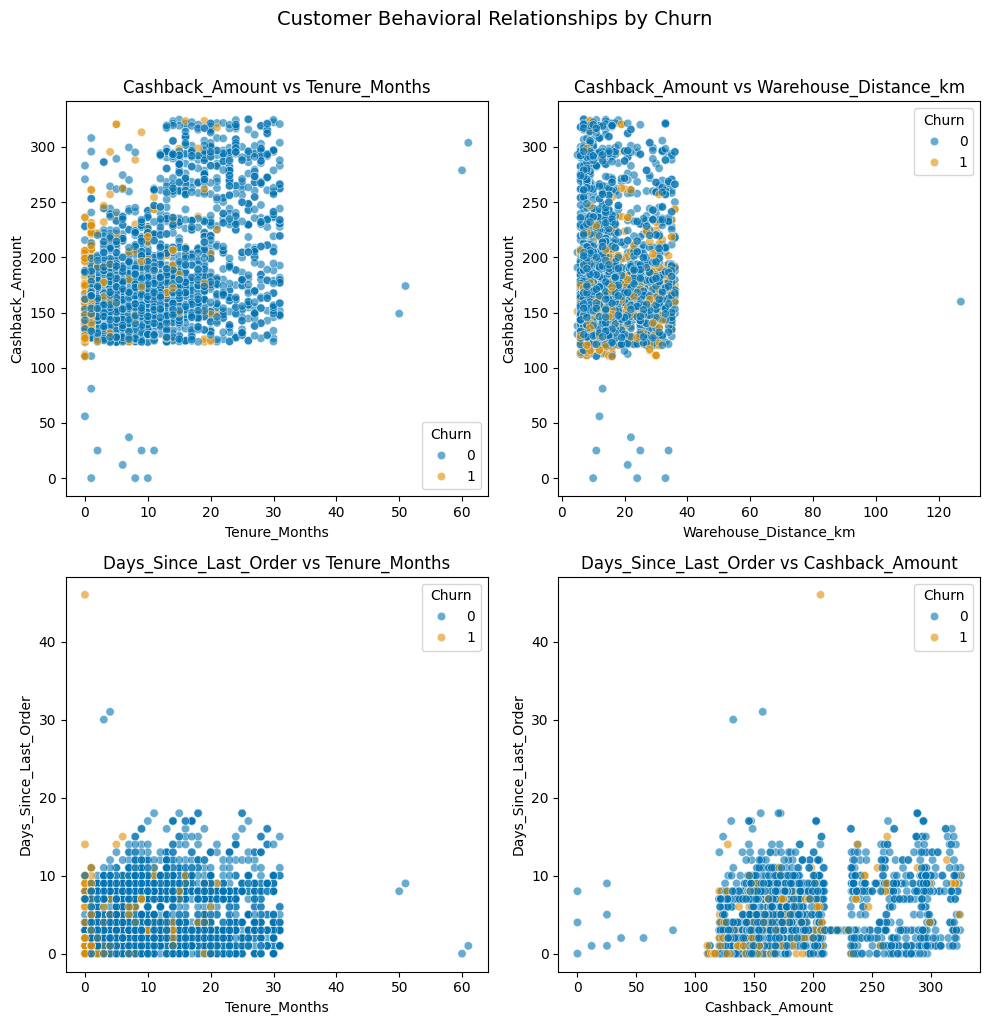

In [16]:
# Define numeric columns for comparison
scatter_pairs = [
    ("Tenure_Months", "Cashback_Amount"),
    ("Warehouse_Distance_km", "Cashback_Amount"),
    ("Tenure_Months", "Days_Since_Last_Order"),
    ("Cashback_Amount", "Days_Since_Last_Order")
]

# Create subplots
fig = plt.figure(figsize=(10,10))
plot = 0

for x_var, y_var in scatter_pairs:
    plot += 1
    ax = plt.subplot(2, 2, plot)
    sns.scatterplot(
        data=ecom_churn_data,
        x=x_var,
        y=y_var,
        hue="Churn",
        palette="colorblind",
        alpha=0.6
    )
    plt.title(f"{y_var} vs {x_var}")
    plt.xlabel(x_var)
    plt.ylabel(y_var)

plt.suptitle("Customer Behavioral Relationships by Churn", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


As you can see in **Tenure vs Cashback** Loyal customers with longer tenure often earn more cashback, especially among non-churned users. **Warehouse Distance vs Cashback**: Churned customers may cluster at higher distances with lower cashback, suggesting delivery inconvenience reduces engagement. **Tenure vs Days Since Last Order**: Long-tenure but inactive customers can indicate potential churn risks — they’ve been loyal but recently disengaged.**Cashback vs Days Since Last Order**: Active customers show more cashback with recent orders, while churners cluster at low cashback and high recency values.

# Customer Behavioral Relationships – Regression and Scatter Analysis

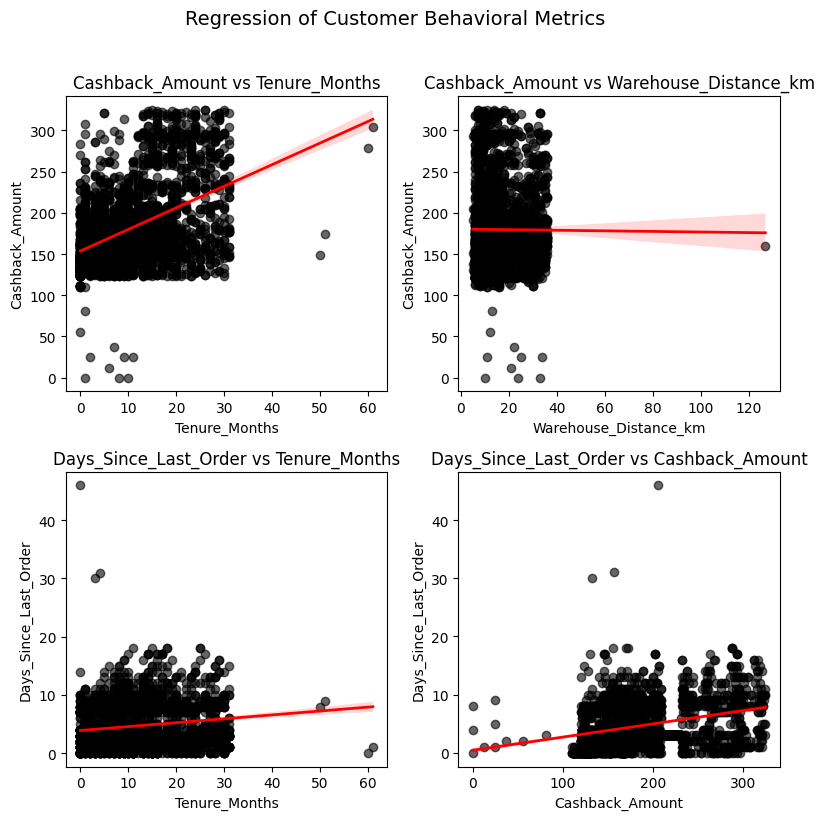

In [17]:
behavior_cols = ["Tenure_Months", "Days_Since_Last_Order", 
                 "Cashback_Amount", "Warehouse_Distance_km"]

reg_pairs = [
    ("Tenure_Months", "Cashback_Amount"),
    ("Warehouse_Distance_km", "Cashback_Amount"),
    ("Tenure_Months", "Days_Since_Last_Order"),
    ("Cashback_Amount", "Days_Since_Last_Order")
]

fig = plt.figure(figsize=(8,8))
plot = 0

for x_var, y_var in reg_pairs:
    plot += 1
    ax = plt.subplot(2, 2, plot)
    sns.regplot(
        x=ecom_churn_data[x_var],
        y=ecom_churn_data[y_var],
        scatter_kws={"color": "black", "alpha": 0.6},
        line_kws={"color": "red", "lw": 2}
    )
    plt.title(f"{y_var} vs {x_var}")
    plt.xlabel(x_var)
    plt.ylabel(y_var)

plt.suptitle("Regression of Customer Behavioral Metrics", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


These plots show how key customer behaviors relate to each other. Longer-tenured customers and those closer to warehouses tend to earn more cashback and order more frequently. Higher cashback corresponds to recent activity, while low engagement and long inactivity cluster with potential churn. Overall, the plots highlight that loyalty, engagement, and convenience are closely linked to retention.

**Histogram of Tenure by Churn**

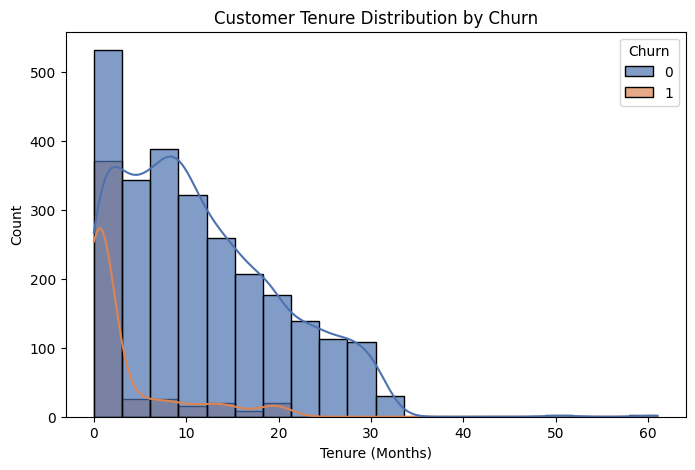

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(data=ecom_churn_data, x="Tenure_Months", hue="Churn", 
             bins=20, kde=True, palette="deep", alpha=0.7)
plt.title("Customer Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Count")
plt.show()


Churned customers generally have shorter tenure, while longer-tenured customers are more likely to remain active. This suggests that new users are at higher risk of leaving early.

**Boxplot of Cashback by Churn**

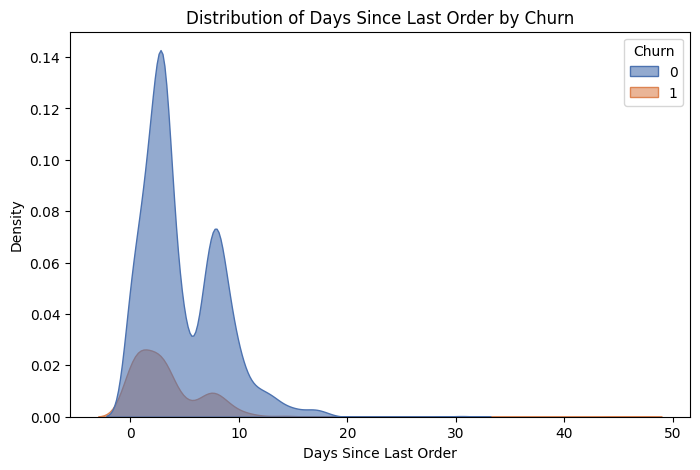

In [19]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=ecom_churn_data, x="Days_Since_Last_Order", hue="Churn", fill=True, palette="deep", alpha=0.6)
plt.title("Distribution of Days Since Last Order by Churn")
plt.xlabel("Days Since Last Order")
plt.ylabel("Density")
plt.show()



Churned customers tend to have longer gaps since their last order, indicating inactivity is a key churn signal.

**Pairplot of Engagement Metrics**

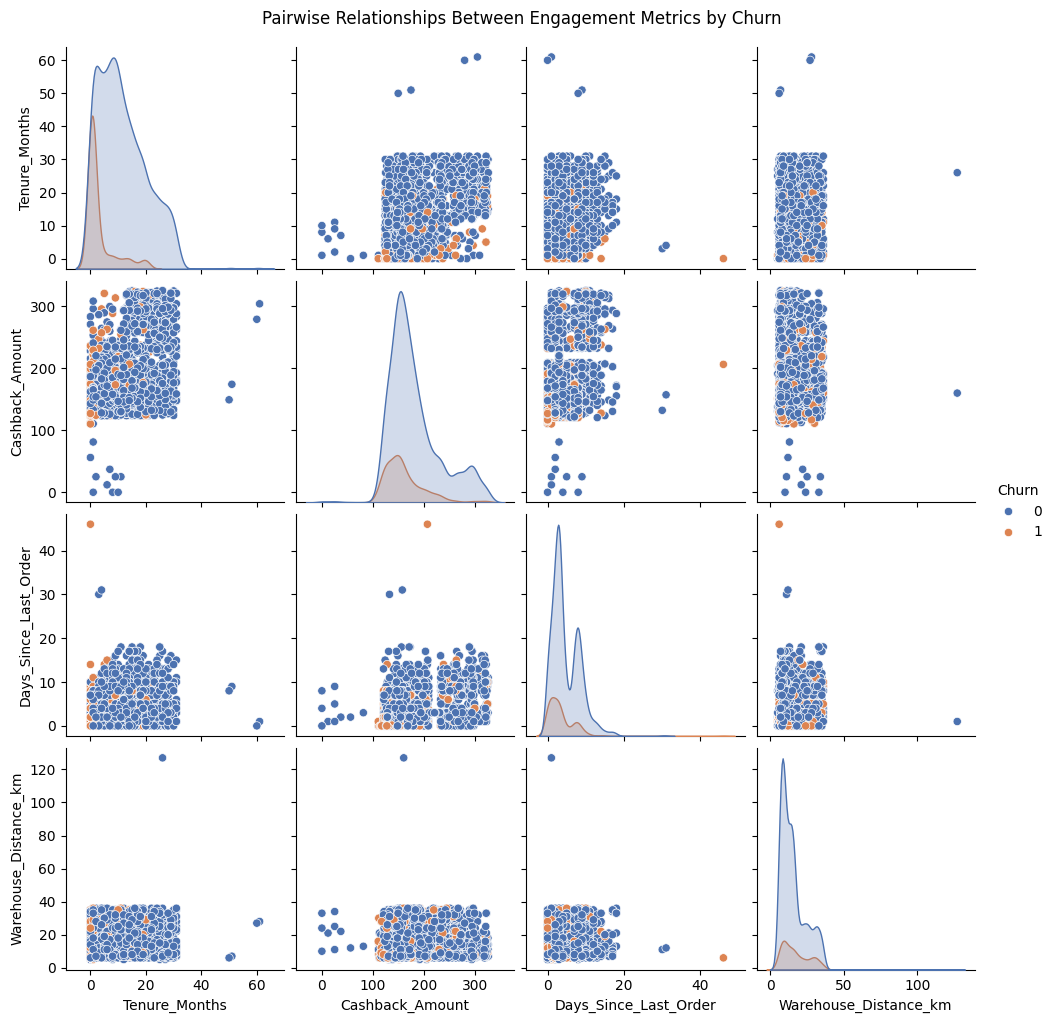

In [20]:
engagement_cols = ["Tenure_Months", "Cashback_Amount", "Days_Since_Last_Order", "Warehouse_Distance_km", "Churn"]
sns.pairplot(ecom_churn_data[engagement_cols], hue="Churn", palette="deep", diag_kind="kde")
plt.suptitle("Pairwise Relationships Between Engagement Metrics by Churn", y=1.02)
plt.show()



Active users cluster with higher tenure and cashback, while churned users show longer inactivity and higher warehouse distance, highlighting multi-factor patterns in churn.

**Stacked Bar Plot of Marital Status vs Churn**

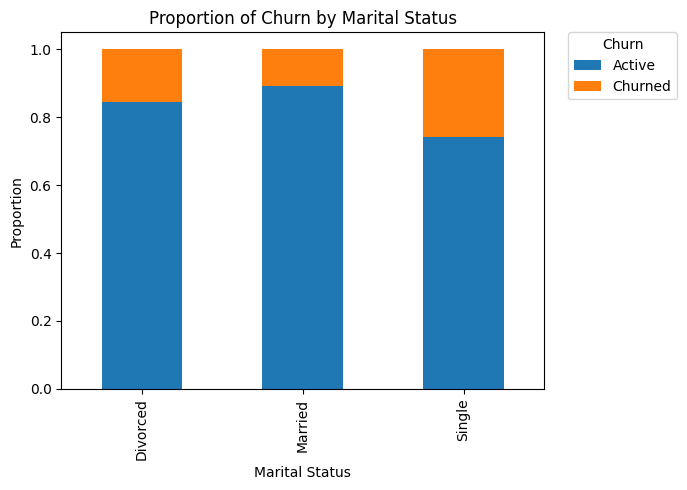

In [23]:
marital_churn = pd.crosstab(ecom_churn_data["Marital_Status"], ecom_churn_data["Churn"], normalize="index")
marital_churn.plot(kind="bar", stacked=True, figsize=(7,5), color=["#1f77b4", "#ff7f0e"])

plt.title("Proportion of Churn by Marital Status")
plt.ylabel("Proportion")
plt.xlabel("Marital Status")
plt.legend(title="Churn", labels=["Active", "Churned"],bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()


Certain marital groups (e.g., Single or Divorced) may have higher churn proportions, suggesting demographic influence on retention.

**Pairplot of Key Customer Metrics by Churn**

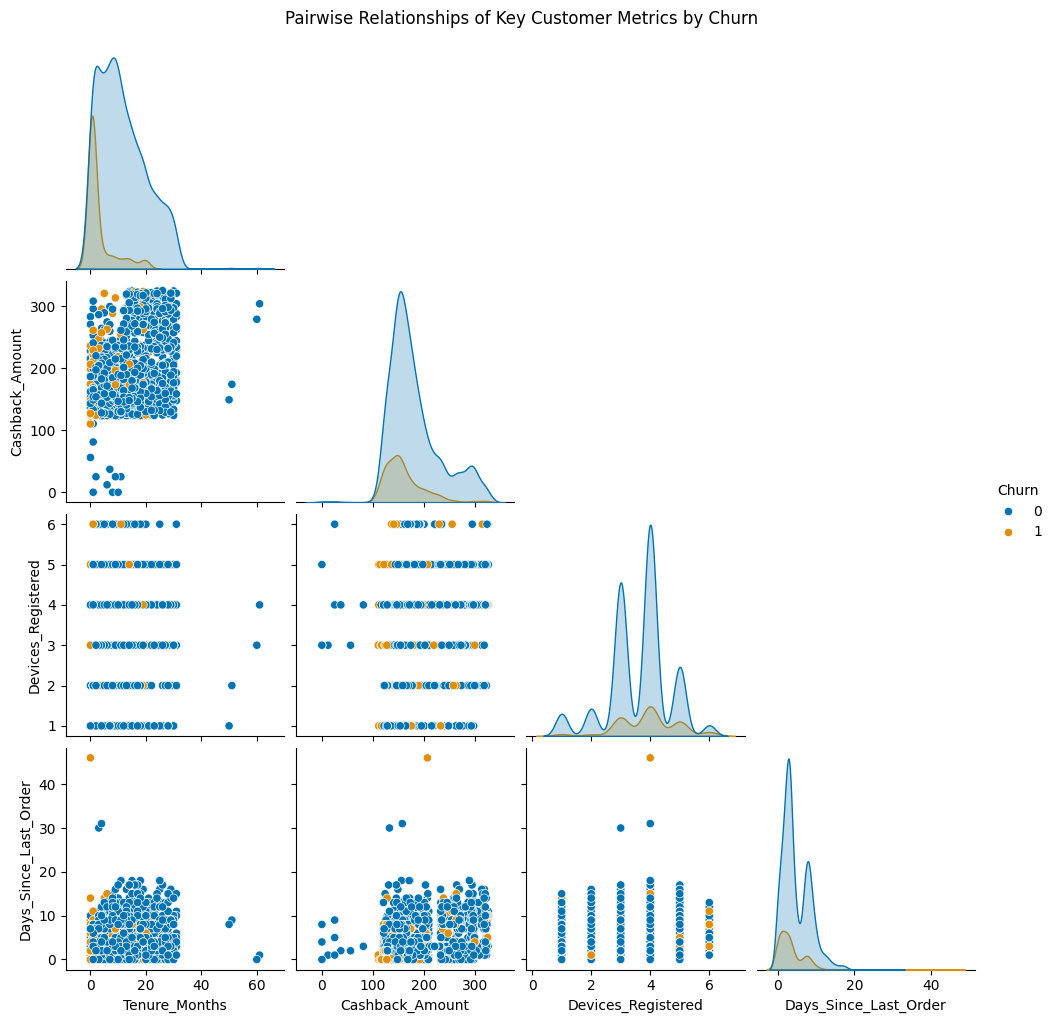

In [22]:
key_metrics = ["Tenure_Months", "Cashback_Amount", "Devices_Registered", "Days_Since_Last_Order", "Churn"]

sns.pairplot(
    ecom_churn_data[key_metrics],
    hue="Churn",
    palette="colorblind",
    diag_kind="kde",
    corner=True
)
plt.suptitle("Pairwise Relationships of Key Customer Metrics by Churn", y=1.02)
plt.show()




The pairplot shows clear differences between active and churned customers across multiple dimensions. Active customers tend to have longer tenure, higher cashback amounts, more registered devices, and shorter periods since their last order, indicating strong engagement and loyalty. Churned customers, in contrast, cluster with lower engagement metrics and longer inactivity, highlighting the key behavioral factors that contribute to churn. This visualization helps identify which combinations of features best distinguish loyal customers from those at risk of leaving.

# Conclusion 

The analysis shows that about 16% of customers have churned, and churn is strongly linked to lower engagement and satisfaction. Churned customers generally have shorter tenure, fewer devices registered, lower cashback, and longer periods since their last order. Demographics, such as marital status, and behavioral signals like complaints also influence churn. Correlation and scatter analyses reinforce that higher satisfaction, consistent activity, and greater rewards are associated with retention. Overall, focusing on improving satisfaction, rewarding loyal customers, and targeting high-risk segments can help reduce churn and increase customer retention.